# FLM Loss Variance Visualizer

This notebook decomposes the current uncommented `FLM.loss` objective in `algo.py`:

`loss` (the current L2 objective), `ce_loss`, `snr_prime_t = 2*t/(1-t)^3`, `dtau_dt = d tau / d t`, `vlb_weight = snr_prime_t / dtau_dt`, and the weighted L2/CE losses.

It evaluates those terms for `N_TAUS` sampled taus per data sample, then provides a per-sample 10x10 view and an aggregate mean/spread view across samples. CE is computed from the same model outputs as L2, so it does not require extra forward passes.

In [35]:
# Main controls
CHECKPOINT_PATH = 'outputs/lm1b/lm1b_flm.ckpt'  # e.g. 'outputs/lm1b/lm1b_flm.ckpt'
DEVICE = 'auto'       # 'auto', 'cuda', or 'cpu'
USE_EMA = True

# Keep model construction lightweight for this notebook. Metrics are not used here.
PATCH_LIGHTWEIGHT_METRICS = True

# These should match the checkpoint you want to inspect.
CONFIG_OVERRIDES = [
    'data=lm1b-wrap',
    'model=small',
    'algo=flm',
    'model.length=128',
    'trainer.devices=1',
    'trainer.num_nodes=1',
    'eval.gen_ppl_eval_model_name_or_path=bert-base-uncased',
    'loader.num_workers=1',
]

# Data controls. Use DATA_SOURCE='manual' if you do not want to touch the dataset cache.
DATA_SOURCE = 'dataloader'  # 'dataloader' or 'manual'
DATA_SPLIT = 'valid'        # 'train' or 'valid'
DATA_CACHE_DIR = '/share/kuleshov/yzs2/data'
FALLBACK_TO_MANUAL = True
MANUAL_TEXTS = [
    'The quick brown fox jumps over the lazy dog.',
    'Language models turn noisy signals into structured text.',
    'A short sentence is enough for a variance sanity check.',
]

# Evaluation controls
N_DATA_SAMPLES = 100
N_TAUS = 1024
TAU_MODE = 'linspace'  # 'random_sorted', 'random', or 'linspace'
TAU_EPS = 1e-5              # avoid the singular tau/t endpoint in line plots
SEED = 0
EVAL_PAIR_CHUNK_SIZE = 8    # number of (sample, tau) pairs per model forward chunk
FIXED_NOISE_PER_SAMPLE = False
TOKEN_REDUCTION = 'valid_mean'  # 'valid_mean' or 'sum'
APPLY_LEARNABLE_LOSS_WEIGHTING = True

# Plot controls
PLOT_N_SAMPLES = 100
GRID_QUANTITY = 'weighted_loss'  # try 'ce_weighted_loss' for cross entropy
PLOT_QUANTITIES = ('loss', 'ce_loss', 'vlb_weight', 'weighted_loss', 'ce_weighted_loss')
LOG_Y = True
AGG_SHADE = 'std'  # 'std', 'sem', or None
ERRORBAR_EVERY = 0 # set to e.g. 8 to draw sparse error bars instead of only shading

In [36]:
from pathlib import Path
import functools
import itertools
import math
import os
import sys

import hydra
import matplotlib.pyplot as plt
import numpy as np
import omegaconf
import torch
import torch.nn.functional as F
from hydra.core.global_hydra import GlobalHydra
from omegaconf import OmegaConf

repo_root = Path.cwd()
if repo_root.name == 'notebooks':
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

if DEVICE == 'auto':
    DEVICE_RESOLVED = 'cuda' if torch.cuda.is_available() else 'cpu'
else:
    DEVICE_RESOLVED = DEVICE

try:
    torch.serialization.add_safe_globals([
        omegaconf.dictconfig.DictConfig,
        omegaconf.base.ContainerMetadata,
        omegaconf.base.Metadata,
    ])
except Exception:
    pass

if PATCH_LIGHTWEIGHT_METRICS:
    import metrics as flm_metrics

    class _NotebookMetrics:
        def __init__(self, *args, **kwargs):
            pass

        def to(self, *args, **kwargs):
            return self

        def reset(self):
            pass

    flm_metrics.Metrics = _NotebookMetrics

import dataloader
import algo

torch.set_grad_enabled(False)
plt.style.use('seaborn-v0_8-whitegrid')
print(f'Repo root: {repo_root}')
print(f'Device: {DEVICE_RESOLVED}')

Repo root: /share/kuleshov/yzs2/flm-og
Device: cuda


In [37]:
def _register_resolver(name, fn):
    if not OmegaConf.has_resolver(name):
        OmegaConf.register_new_resolver(name, fn)


def _resolve_path(path):
    if path is None or str(path) == '':
        return None
    path = Path(path).expanduser()
    if not path.is_absolute():
        path = repo_root / path
    return path


def compose_flm_config(overrides=CONFIG_OVERRIDES,
                       checkpoint_path=CHECKPOINT_PATH,
                       data_cache_dir=DATA_CACHE_DIR):
    _register_resolver('cwd', os.getcwd)
    _register_resolver('device_count', lambda: max(torch.cuda.device_count(), 1))
    _register_resolver('eval', eval)
    _register_resolver('div_up', lambda x, y: (x + y - 1) // y)

    if GlobalHydra.instance().is_initialized():
        GlobalHydra.instance().clear()
    with hydra.initialize_config_dir(
        config_dir=str(repo_root / 'configs'), version_base=None
    ):
        cfg = hydra.compose(config_name='config', overrides=list(overrides))

    ckpt_path = _resolve_path(checkpoint_path)
    if ckpt_path is not None:
        cfg.eval.checkpoint_path = str(ckpt_path)
    if data_cache_dir:
        cfg.data.cache_dir = str(Path(data_cache_dir).expanduser())
    cfg.mode = 'ppl_eval'
    return cfg


def _model_class_for_config(cfg):
    if cfg.algo.name != 'flm':
        raise ValueError(
            f'This notebook targets the FLM class; got algo.name={cfg.algo.name!r}'
        )
    return algo.FLM


def load_flm(checkpoint_path=CHECKPOINT_PATH, use_ema=USE_EMA):
    cfg = compose_flm_config(checkpoint_path=checkpoint_path)
    tokenizer = dataloader.get_tokenizer(cfg)
    model_cls = _model_class_for_config(cfg)
    ckpt_path = _resolve_path(checkpoint_path)

    if ckpt_path is None:
        print('CHECKPOINT_PATH is empty: using a randomly initialized FLM.')
        model = model_cls(cfg, tokenizer=tokenizer)
    else:
        if not ckpt_path.exists():
            raise FileNotFoundError(f'Checkpoint not found: {ckpt_path}')
        model = model_cls.load_from_checkpoint(
            str(ckpt_path),
            tokenizer=tokenizer,
            config=cfg,
            map_location=DEVICE_RESOLVED,
            weights_only=False,
        )

    model = model.to(DEVICE_RESOLVED)
    if getattr(model, 'ema', None) is not None:
        model.ema.move_shadow_params_to_device(model.device)
    cfg.eval.disable_ema = not bool(use_ema)
    if use_ema and getattr(model, 'ema', None) is not None:
        model._eval_mode()
    else:
        model.eval()
        model.backbone.eval()
    print(
        f'Loaded {cfg.algo.name} on {DEVICE_RESOLVED}; '
        f'vocab={model.vocab_size}; length={cfg.model.length}; '
        f'tau=[{cfg.algo.t_min}, {cfg.algo.t_max}]'
    )
    return cfg, tokenizer, model


cfg, tokenizer, model = load_flm()

Resuming training from checkpoint...
Copying EMA parameters to model
Loaded flm on cuda; vocab=30522; length=128; tau=[0.0, 1.0]


In [38]:
def _repeat_to_length(items, n):
    if len(items) == 0:
        raise ValueError('MANUAL_TEXTS must contain at least one string.')
    return [items[i % len(items)] for i in range(n)]


def load_manual_batch(cfg, tokenizer, n=N_DATA_SAMPLES, texts=MANUAL_TEXTS):
    texts = _repeat_to_length(list(texts), int(n))
    encoded = tokenizer(
        texts,
        max_length=int(cfg.model.length),
        padding='max_length',
        truncation=True,
        add_special_tokens=True,
        return_tensors='pt',
    )
    return {
        'input_ids': encoded['input_ids'],
        'attention_mask': encoded.get('attention_mask', torch.ones_like(encoded['input_ids'])),
    }


def _dataset_mode(cfg, split):
    if split == 'train':
        return 'train'
    if cfg.data.valid in ['text8', 'lm1b', 'ag_news']:
        return 'test'
    return 'validation'


def load_dataset_batch(cfg, tokenizer, n=N_DATA_SAMPLES,
                       split=DATA_SPLIT, seed=SEED):
    mode = _dataset_mode(cfg, split)
    dataset_name = cfg.data.train if split == 'train' else cfg.data.valid
    dataset = dataloader.get_dataset(
        dataset_name,
        tokenizer,
        wrap=cfg.data.wrap,
        mode=mode,
        cache_dir=cfg.data.cache_dir,
        insert_eos=cfg.data.insert_train_eos if split == 'train' else cfg.data.insert_valid_eos,
        block_size=int(cfg.model.length),
        streaming=cfg.data.streaming,
        num_proc=int(cfg.loader.num_workers),
        revision=cfg.data.get('train_revision' if split == 'train' else 'valid_revision', None),
        config=cfg,
    )

    if hasattr(dataset, '__len__'):
        total = len(dataset)
        count = min(int(n), total)
        rng = np.random.default_rng(seed)
        indices = rng.choice(total, size=count, replace=False)
        rows = [dataset[int(i)] for i in indices]
    else:
        rows = list(itertools.islice(iter(dataset), int(n)))

    batch = {}
    for key in ['input_ids', 'attention_mask']:
        values = [torch.as_tensor(row[key]) for row in rows]
        batch[key] = torch.stack(values, dim=0)
    return batch


def load_visualization_batch(source=DATA_SOURCE):
    if source == 'manual':
        return load_manual_batch(cfg, tokenizer)
    if source == 'dataloader':
        return load_dataset_batch(cfg, tokenizer)
    raise ValueError(f'Unknown DATA_SOURCE: {source}')


try:
    batch = load_visualization_batch(DATA_SOURCE)
except Exception as exc:
    if DATA_SOURCE != 'manual' and FALLBACK_TO_MANUAL:
        print(f'Dataloader batch failed, falling back to MANUAL_TEXTS. Original error: {exc}')
        batch = load_manual_batch(cfg, tokenizer)
    else:
        raise

input_ids = batch['input_ids'].to(DEVICE_RESOLVED)
attention_mask = batch.get('attention_mask', torch.ones_like(input_ids)).to(DEVICE_RESOLVED).float()

print(f'input_ids shape: {tuple(input_ids.shape)}')
print('First sample preview:')
print(tokenizer.decode(input_ids[0].detach().cpu().tolist()[: min(128, input_ids.shape[1])]))

input_ids shape: (100, 128)
First sample preview:
[CLS] have increased prices ahead of announcing of the " freeze, " thereby ensuring they do not lose out from keeping prices unchanged in january. [CLS] " it should be abolished without further ado, " said malcolm smart, director of amnesty international's middle east and north africa program. [CLS] president bush, left, makes a point as french president nicolas sarkozy listens saturday in paris. [CLS] the company has not received any reports of illness or allergic reactions caused by consuming kroger hazelnut spread and has issued this recall as a precautionary measure. [CLS] this was wales's eighth six nations victory on the spin, [CLS]


In [39]:
def make_tau_values(cfg, n=N_TAUS, mode=TAU_MODE, seed=SEED, eps=TAU_EPS):
    tau_min = float(cfg.algo.t_min)
    tau_max = float(cfg.algo.t_max)
    lo = tau_min + float(eps)
    hi = tau_max - float(eps)
    if not hi > lo:
        raise ValueError(f'Invalid tau interval after eps: [{lo}, {hi}]')
    if mode == 'linspace':
        tau = torch.linspace(lo, hi, int(n), dtype=torch.float32)
    elif mode in {'random', 'random_sorted'}:
        generator = torch.Generator().manual_seed(int(seed))
        tau = lo + (hi - lo) * torch.rand(int(n), generator=generator)
        if mode == 'random_sorted':
            tau = tau.sort().values
    else:
        raise ValueError(f'Unknown TAU_MODE: {mode}')
    return tau


def _reduce_tokens(values, mask, mode=TOKEN_REDUCTION):
    if mode == 'valid_mean':
        denom = mask.sum(dim=-1).clamp_min(1.0)
        return (values * mask).sum(dim=-1) / denom
    if mode == 'sum':
        return (values * mask).sum(dim=-1)
    raise ValueError(f'Unknown TOKEN_REDUCTION: {mode}')


def _make_generator(seed, device):
    try:
        return torch.Generator(device=device).manual_seed(int(seed))
    except Exception:
        return torch.Generator().manual_seed(int(seed))


def _maybe_apply_learnable_loss_weighting(model, tau, loss_token):
    enabled = bool(getattr(model.config.algo, 'learnable_loss_weighting', False))
    if not (APPLY_LEARNABLE_LOSS_WEIGHTING and enabled):
        return loss_token
    if not hasattr(model.backbone, 'learnable_loss_weighting'):
        return loss_token
    loss_weight = model.backbone.learnable_loss_weighting(tau).unsqueeze(-1)
    return torch.exp(-loss_weight) * loss_token + loss_weight


def _init_curve_storage(num_samples, num_taus):
    return {
        'loss': np.empty((num_samples, num_taus), dtype=np.float64),
        'loss_for_vlb': np.empty((num_samples, num_taus), dtype=np.float64),
        'weighted_loss': np.empty((num_samples, num_taus), dtype=np.float64),
        'ce_loss': np.empty((num_samples, num_taus), dtype=np.float64),
        'ce_loss_for_vlb': np.empty((num_samples, num_taus), dtype=np.float64),
        'ce_weighted_loss': np.empty((num_samples, num_taus), dtype=np.float64),
    }


@torch.inference_mode()
def evaluate_flm_loss_terms(model, input_ids, attention_mask, tau_values,
                            chunk_size=EVAL_PAIR_CHUNK_SIZE,
                            fixed_noise_per_sample=FIXED_NOISE_PER_SAMPLE,
                            seed=SEED):
    model.eval()
    device = next(model.parameters()).device
    input_ids = input_ids.to(device)
    attention_mask = attention_mask.to(device).float()
    tau_values = tau_values.detach().float().cpu()
    tau_device = tau_values.to(device)
    num_samples, _ = input_ids.shape
    num_taus = tau_values.numel()

    curves = _init_curve_storage(num_samples, num_taus)
    t_grid = model._tau_to_t(tau_device).detach()
    snr_prime_grid = 2 * t_grid / (1 - t_grid) ** 3
    dtau_dt_grid = model._d_tau_by_d_t(t_grid)
    vlb_weight_grid = snr_prime_grid / dtau_dt_grid

    curves['tau'] = tau_values.numpy()
    curves['t'] = t_grid.detach().cpu().numpy()
    curves['snr_prime_t'] = snr_prime_grid.detach().cpu().numpy()
    curves['dtau_dt'] = dtau_dt_grid.detach().cpu().numpy()
    curves['vlb_weight'] = vlb_weight_grid.detach().cpu().numpy()
    curves['token_reduction'] = TOKEN_REDUCTION
    curves['fixed_noise_per_sample'] = bool(fixed_noise_per_sample)

    if fixed_noise_per_sample:
        for sample_idx in range(num_samples):
            x0 = input_ids[sample_idx:sample_idx + 1]
            mask = attention_mask[sample_idx:sample_idx + 1]
            target_data = F.one_hot(x0, model.vocab_size).float()
            generator = _make_generator(int(seed) + sample_idx, device)
            noise = torch.randn(
                target_data.shape,
                generator=generator,
                device=device,
                dtype=torch.float32,
            )
            for start in range(0, num_taus, int(chunk_size)):
                end = min(start + int(chunk_size), num_taus)
                tau = tau_device[start:end]
                t = model._tau_to_t(tau)
                batch_size = tau.numel()
                x_t = ((1 - t).view(-1, 1, 1) * noise.expand(batch_size, -1, -1)
                       + t.view(-1, 1, 1) * target_data.expand(batch_size, -1, -1))
                target = target_data.expand(batch_size, -1, -1)
                mask_chunk = mask.expand(batch_size, -1)
                f = model.forward(x_t, tau)
                pred_probs = f.exp()
                loss_token = 0.5 * ((target - pred_probs) ** 2).sum(dim=-1)
                ce_loss_token = -(target * f).sum(dim=-1)
                loss_for_vlb = _maybe_apply_learnable_loss_weighting(model, tau, loss_token)
                ce_loss_for_vlb = _maybe_apply_learnable_loss_weighting(model, tau, ce_loss_token)
                vlb_weight = vlb_weight_grid[start:end].to(device)
                curves['loss'][sample_idx, start:end] = _reduce_tokens(
                    loss_token, mask_chunk
                ).detach().cpu().numpy()
                curves['loss_for_vlb'][sample_idx, start:end] = _reduce_tokens(
                    loss_for_vlb, mask_chunk
                ).detach().cpu().numpy()
                curves['weighted_loss'][sample_idx, start:end] = _reduce_tokens(
                    loss_for_vlb * vlb_weight[:, None], mask_chunk
                ).detach().cpu().numpy()
                curves['ce_loss'][sample_idx, start:end] = _reduce_tokens(
                    ce_loss_token, mask_chunk
                ).detach().cpu().numpy()
                curves['ce_loss_for_vlb'][sample_idx, start:end] = _reduce_tokens(
                    ce_loss_for_vlb, mask_chunk
                ).detach().cpu().numpy()
                curves['ce_weighted_loss'][sample_idx, start:end] = _reduce_tokens(
                    ce_loss_for_vlb * vlb_weight[:, None], mask_chunk
                ).detach().cpu().numpy()
    else:
        torch.manual_seed(int(seed))
        total_pairs = num_samples * num_taus
        for start in range(0, total_pairs, int(chunk_size)):
            end = min(start + int(chunk_size), total_pairs)
            flat = torch.arange(start, end, device=device)
            sample_idx = torch.div(flat, num_taus, rounding_mode='floor')
            tau_idx = flat % num_taus
            x0 = input_ids[sample_idx]
            mask = attention_mask[sample_idx]
            tau = tau_device[tau_idx]
            t = model._tau_to_t(tau)
            x_t, target_data = model.corrupt_continuous(x0, t)
            f = model.forward(x_t, tau)
            pred_probs = f.exp()
            loss_token = 0.5 * ((target_data - pred_probs) ** 2).sum(dim=-1)
            ce_loss_token = -(target_data * f).sum(dim=-1)
            loss_for_vlb = _maybe_apply_learnable_loss_weighting(model, tau, loss_token)
            ce_loss_for_vlb = _maybe_apply_learnable_loss_weighting(model, tau, ce_loss_token)
            vlb_weight = vlb_weight_grid[tau_idx].to(device)

            sample_np = sample_idx.detach().cpu().numpy()
            tau_np = tau_idx.detach().cpu().numpy()
            curves['loss'][sample_np, tau_np] = _reduce_tokens(
                loss_token, mask
            ).detach().cpu().numpy()
            curves['loss_for_vlb'][sample_np, tau_np] = _reduce_tokens(
                loss_for_vlb, mask
            ).detach().cpu().numpy()
            curves['weighted_loss'][sample_np, tau_np] = _reduce_tokens(
                loss_for_vlb * vlb_weight[:, None], mask
            ).detach().cpu().numpy()
            curves['ce_loss'][sample_np, tau_np] = _reduce_tokens(
                ce_loss_token, mask
            ).detach().cpu().numpy()
            curves['ce_loss_for_vlb'][sample_np, tau_np] = _reduce_tokens(
                ce_loss_for_vlb, mask
            ).detach().cpu().numpy()
            curves['ce_weighted_loss'][sample_np, tau_np] = _reduce_tokens(
                ce_loss_for_vlb * vlb_weight[:, None], mask
            ).detach().cpu().numpy()

    return curves


def matrix_for(curves, name):
    values = np.asarray(curves[name])
    if values.ndim == 1:
        return np.broadcast_to(values[None, :], curves['loss'].shape)
    return values


def summarize_curves(curves, names=PLOT_QUANTITIES):
    print(f"{'term':<16} {'mean':>13} {'std':>13} {'min':>13} {'median':>13} {'max':>13}")
    for name in names:
        values = matrix_for(curves, name).reshape(-1)
        values = values[np.isfinite(values)]
        print(
            f"{name:<16} {values.mean():13.6g} {values.std():13.6g} "
            f"{values.min():13.6g} {np.median(values):13.6g} {values.max():13.6g}"
        )

In [40]:
tau_values = make_tau_values(cfg)
curves = evaluate_flm_loss_terms(model, input_ids, attention_mask, tau_values)
summarize_curves(curves)

/share/kuleshov/yzs2/flm-og/models/dit.py:476: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


term                      mean           std           min        median           max
loss                  0.186685     0.0788589     0.0422856      0.164977      0.504563
ce_loss                2.15858       1.09954      0.344452       1.87519       7.54505
vlb_weight             470.311       13214.7       20.7444       25.9893        423090
weighted_loss          59.4618       1614.94       1.03913       4.66752       80664.2
ce_weighted_loss       652.445         17870       8.62368       53.6724   1.08714e+06


## Variance Diagnostics

Use these cells to answer three questions:

1. Is the weighted L2 or CE loss variance mostly a sample effect, a tau effect, or residual sample-by-tau/noise variation?
2. If tau drives it, does the unweighted objective vary with tau, or is `vlb_weight` amplifying it?
3. If `vlb_weight` drives it, is the dominant log-scale variation from `snr_prime_t` or `dtau_dt`?

In [41]:
def _safe_log(values, eps=1e-30):
    values = np.asarray(values, dtype=np.float64)
    positive = values[np.isfinite(values) & (values > 0)]
    floor = eps if positive.size == 0 else max(float(eps), float(positive.min()) * 1e-6)
    return np.log(np.clip(values, floor, None))


def variance_decomposition(values):
    y = np.asarray(values, dtype=np.float64)
    if y.ndim != 2:
        raise ValueError(f'Expected a [samples, taus] matrix, got shape {y.shape}')
    if not np.isfinite(y).all():
        raise ValueError('Variance decomposition expects finite values. Check tau endpoints/log scale.')

    overall = y.mean()
    sample_effect = y.mean(axis=1) - overall
    tau_effect = y.mean(axis=0) - overall
    residual = y - overall - sample_effect[:, None] - tau_effect[None, :]
    total = np.mean((y - overall) ** 2)
    pieces = {
        'sample': np.mean(sample_effect ** 2),
        'tau': np.mean(tau_effect ** 2),
        'residual': np.mean(residual ** 2),
        'total': total,
    }
    denom = total if total > 0 else 1.0
    pieces['sample_pct'] = 100.0 * pieces['sample'] / denom
    pieces['tau_pct'] = 100.0 * pieces['tau'] / denom
    pieces['residual_pct'] = 100.0 * pieces['residual'] / denom
    return pieces


def print_variance_decomposition(curves,
                                 quantities=('loss', 'vlb_weight', 'weighted_loss')):
    rows = {}
    print(f"{'term':<16} {'sample %':>10} {'tau %':>10} {'resid %':>10} {'total var':>13}")
    for name in quantities:
        pieces = variance_decomposition(matrix_for(curves, name))
        rows[name] = pieces
        print(
            f"{name:<16} {pieces['sample_pct']:10.2f} {pieces['tau_pct']:10.2f} "
            f"{pieces['residual_pct']:10.2f} {pieces['total']:13.6g}"
        )
    return rows


def print_log_product_diagnostics(curves):
    log_loss = _safe_log(matrix_for(curves, 'loss_for_vlb')).reshape(-1)
    log_weight = _safe_log(matrix_for(curves, 'vlb_weight')).reshape(-1)
    log_weighted = _safe_log(matrix_for(curves, 'weighted_loss')).reshape(-1)

    loss_var = log_loss.var()
    weight_var = log_weight.var()
    covariance = np.mean((log_loss - log_loss.mean()) * (log_weight - log_weight.mean()))
    total = log_weighted.var()
    denom = total if total > 0 else 1.0

    print('log(weighted_loss) = log(loss_for_vlb) + log(vlb_weight)')
    print(f"{'piece':<24} {'value':>13} {'share of total':>16}")
    print(f"{'var(log loss)':<24} {loss_var:13.6g} {100 * loss_var / denom:15.2f}%")
    print(f"{'var(log vlb_weight)':<24} {weight_var:13.6g} {100 * weight_var / denom:15.2f}%")
    print(f"{'2 * cov':<24} {2 * covariance:13.6g} {100 * 2 * covariance / denom:15.2f}%")
    print(f"{'total':<24} {total:13.6g} {100.0:15.2f}%")
    return {
        'loss_var': loss_var,
        'weight_var': weight_var,
        'two_cov': 2 * covariance,
        'total': total,
    }


def print_weight_term_diagnostics(curves):
    log_snr_prime = _safe_log(curves['snr_prime_t']).reshape(-1)
    log_dtau_dt = _safe_log(curves['dtau_dt']).reshape(-1)
    log_vlb_weight = _safe_log(curves['vlb_weight']).reshape(-1)

    snr_var = log_snr_prime.var()
    dtau_var = log_dtau_dt.var()
    covariance = np.mean(
        (log_snr_prime - log_snr_prime.mean())
        * (log_dtau_dt - log_dtau_dt.mean())
    )
    total = log_vlb_weight.var()
    denom = total if total > 0 else 1.0

    print('log(vlb_weight) = log(snr_prime_t) - log(dtau_dt)')
    print(f"{'piece':<24} {'value':>13} {'share of total':>16}")
    print(f"{'var(log snr_prime)':<24} {snr_var:13.6g} {100 * snr_var / denom:15.2f}%")
    print(f"{'var(log dtau_dt)':<24} {dtau_var:13.6g} {100 * dtau_var / denom:15.2f}%")
    print(f"{'-2 * cov':<24} {-2 * covariance:13.6g} {100 * -2 * covariance / denom:15.2f}%")
    print(f"{'total':<24} {total:13.6g} {100.0:15.2f}%")
    return {
        'snr_var': snr_var,
        'dtau_var': dtau_var,
        'minus_two_cov': -2 * covariance,
        'total': total,
    }


def run_variance_diagnostics(curves):
    print('Two-way variance decomposition across samples and taus')
    decomposition = print_variance_decomposition(curves)
    print('\nLoss-vs-weight multiplicative diagnostic')
    product = print_log_product_diagnostics(curves)
    print('\nVLB weight numerator-vs-denominator diagnostic')
    weight_terms = print_weight_term_diagnostics(curves)
    return {
        'decomposition': decomposition,
        'product': product,
        'weight_terms': weight_terms,
    }


def plot_variance_diagnostics(curves, diagnostics=None):
    if diagnostics is None:
        diagnostics = {
            'decomposition': {
                name: variance_decomposition(matrix_for(curves, name))
                for name in ('loss', 'vlb_weight', 'weighted_loss')
            },
            'product': print_log_product_diagnostics(curves),
            'weight_terms': print_weight_term_diagnostics(curves),
        }

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

    names = ['loss', 'vlb_weight', 'weighted_loss']
    sample = [diagnostics['decomposition'][name]['sample_pct'] for name in names]
    tau = [diagnostics['decomposition'][name]['tau_pct'] for name in names]
    resid = [diagnostics['decomposition'][name]['residual_pct'] for name in names]
    x = np.arange(len(names))
    axes[0].bar(x, sample, label='sample')
    axes[0].bar(x, tau, bottom=sample, label='tau')
    axes[0].bar(x, resid, bottom=np.asarray(sample) + np.asarray(tau), label='residual')
    axes[0].set_xticks(x, names, rotation=20)
    axes[0].set_ylabel('% of total variance')
    axes[0].set_title('Sample vs tau vs residual')
    axes[0].legend(frameon=False)

    product = diagnostics['product']
    product_names = ['log loss', 'log weight', '2cov']
    product_vals = [product['loss_var'], product['weight_var'], product['two_cov']]
    axes[1].bar(product_names, product_vals, color=['#2563eb', '#0f766e', '#a16207'])
    axes[1].axhline(0, color='black', lw=0.8)
    axes[1].set_title('log(weighted_loss) pieces')
    axes[1].set_ylabel('variance contribution')

    weight_terms = diagnostics['weight_terms']
    weight_names = ['log snr_prime', 'log dtau_dt', '-2cov']
    weight_vals = [
        weight_terms['snr_var'],
        weight_terms['dtau_var'],
        weight_terms['minus_two_cov'],
    ]
    axes[2].bar(weight_names, weight_vals, color=['#2563eb', '#0f766e', '#a16207'])
    axes[2].axhline(0, color='black', lw=0.8)
    axes[2].set_title('log(vlb_weight) pieces')
    axes[2].set_ylabel('variance contribution')

    fig.tight_layout()
    return fig

In [42]:
OBJECTIVE_KEYS = {
    'l2': {
        'loss': 'loss',
        'loss_for_vlb': 'loss_for_vlb',
        'weighted_loss': 'weighted_loss',
        'label': 'L2',
    },
    'ce': {
        'loss': 'ce_loss',
        'loss_for_vlb': 'ce_loss_for_vlb',
        'weighted_loss': 'ce_weighted_loss',
        'label': 'CE',
    },
}


def objective_keys(objective='l2'):
    if objective not in OBJECTIVE_KEYS:
        raise ValueError(f'objective must be one of {sorted(OBJECTIVE_KEYS)}, got {objective!r}')
    return OBJECTIVE_KEYS[objective]


def print_log_product_diagnostics(curves, objective='l2'):
    keys = objective_keys(objective)
    log_loss = _safe_log(matrix_for(curves, keys['loss_for_vlb'])).reshape(-1)
    log_weight = _safe_log(matrix_for(curves, 'vlb_weight')).reshape(-1)
    log_weighted = _safe_log(matrix_for(curves, keys['weighted_loss'])).reshape(-1)

    loss_var = log_loss.var()
    weight_var = log_weight.var()
    covariance = np.mean((log_loss - log_loss.mean()) * (log_weight - log_weight.mean()))
    total = log_weighted.var()
    denom = total if total > 0 else 1.0

    print(
        f"log({keys['weighted_loss']}) = "
        f"log({keys['loss_for_vlb']}) + log(vlb_weight)"
    )
    print(f"{'piece':<24} {'value':>13} {'share of total':>16}")
    print(f"{'var(log objective)':<24} {loss_var:13.6g} {100 * loss_var / denom:15.2f}%")
    print(f"{'var(log vlb_weight)':<24} {weight_var:13.6g} {100 * weight_var / denom:15.2f}%")
    print(f"{'2 * cov':<24} {2 * covariance:13.6g} {100 * 2 * covariance / denom:15.2f}%")
    print(f"{'total':<24} {total:13.6g} {100.0:15.2f}%")
    return {
        'loss_var': loss_var,
        'weight_var': weight_var,
        'two_cov': 2 * covariance,
        'total': total,
    }


def run_variance_diagnostics(curves, objective='l2'):
    keys = objective_keys(objective)
    quantities = (keys['loss'], 'vlb_weight', keys['weighted_loss'])
    print(f"Two-way variance decomposition across samples and taus ({keys['label']})")
    decomposition = print_variance_decomposition(curves, quantities=quantities)
    print(f"\n{keys['label']} objective-vs-weight multiplicative diagnostic")
    product = print_log_product_diagnostics(curves, objective=objective)
    print('\nVLB weight numerator-vs-denominator diagnostic')
    weight_terms = print_weight_term_diagnostics(curves)
    return {
        'objective': objective,
        'decomposition': decomposition,
        'product': product,
        'weight_terms': weight_terms,
    }


def plot_variance_diagnostics(curves, diagnostics=None, objective='l2'):
    keys = objective_keys(objective)
    names = [keys['loss'], 'vlb_weight', keys['weighted_loss']]
    if diagnostics is None:
        diagnostics = {
            'decomposition': {
                name: variance_decomposition(matrix_for(curves, name))
                for name in names
            },
            'product': print_log_product_diagnostics(curves, objective=objective),
            'weight_terms': print_weight_term_diagnostics(curves),
        }

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

    sample = [diagnostics['decomposition'][name]['sample_pct'] for name in names]
    tau = [diagnostics['decomposition'][name]['tau_pct'] for name in names]
    resid = [diagnostics['decomposition'][name]['residual_pct'] for name in names]
    x = np.arange(len(names))
    axes[0].bar(x, sample, label='sample')
    axes[0].bar(x, tau, bottom=sample, label='tau')
    axes[0].bar(x, resid, bottom=np.asarray(sample) + np.asarray(tau), label='residual')
    axes[0].set_xticks(x, names, rotation=20)
    axes[0].set_ylabel('% of total variance')
    axes[0].set_title(f"{keys['label']}: sample vs tau vs residual")
    axes[0].legend(frameon=False)

    product = diagnostics['product']
    product_names = ['log objective', 'log weight', '2cov']
    product_vals = [product['loss_var'], product['weight_var'], product['two_cov']]
    axes[1].bar(product_names, product_vals, color=['#2563eb', '#0f766e', '#a16207'])
    axes[1].axhline(0, color='black', lw=0.8)
    axes[1].set_title(f"{keys['label']}: log(weighted objective) pieces")
    axes[1].set_ylabel('variance contribution')

    weight_terms = diagnostics['weight_terms']
    weight_names = ['log snr_prime', 'log dtau_dt', '-2cov']
    weight_vals = [
        weight_terms['snr_var'],
        weight_terms['dtau_var'],
        weight_terms['minus_two_cov'],
    ]
    axes[2].bar(weight_names, weight_vals, color=['#2563eb', '#0f766e', '#a16207'])
    axes[2].axhline(0, color='black', lw=0.8)
    axes[2].set_title('log(vlb_weight) pieces')
    axes[2].set_ylabel('variance contribution')

    fig.tight_layout()
    return fig

Two-way variance decomposition across samples and taus (L2)
term               sample %      tau %    resid %     total var
loss                  11.10      83.59       5.31    0.00621873
vlb_weight             0.00     100.00       0.00   1.74629e+08
weighted_loss          0.01      95.12       4.88   2.60804e+06

L2 objective-vs-weight multiplicative diagnostic
log(weighted_loss) = log(loss_for_vlb) + log(vlb_weight)
piece                            value   share of total
var(log objective)            0.146899           21.91%
var(log vlb_weight)           0.568282           84.76%
2 * cov                     -0.0446889           -6.67%
total                         0.670492          100.00%

VLB weight numerator-vs-denominator diagnostic
log(vlb_weight) = log(snr_prime_t) - log(dtau_dt)
piece                            value   share of total
var(log snr_prime)            0.545527           96.00%
var(log dtau_dt)              0.880133          154.88%
-2 * cov                     -0

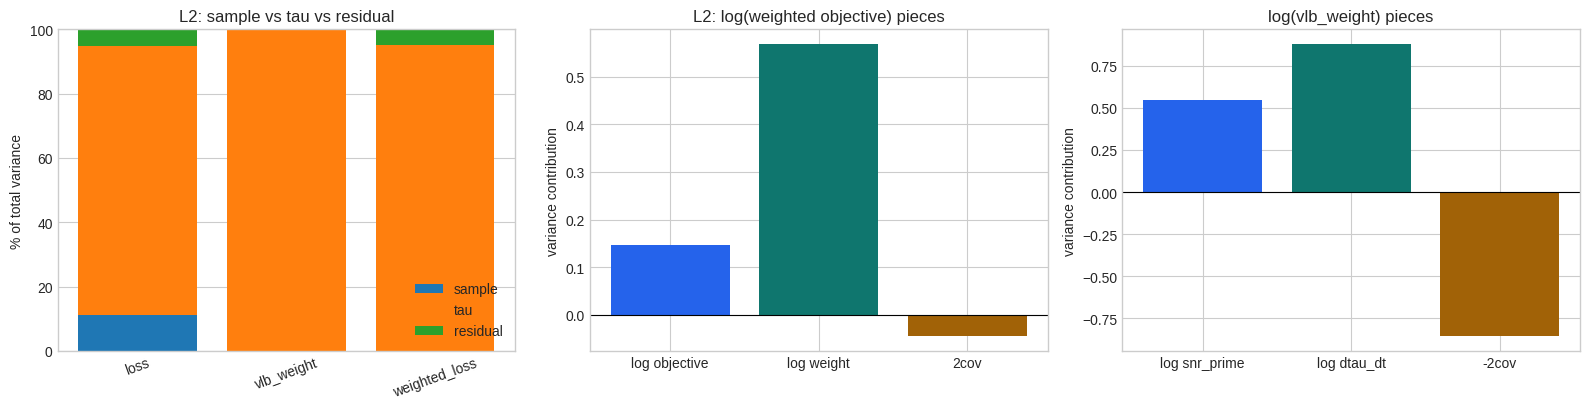

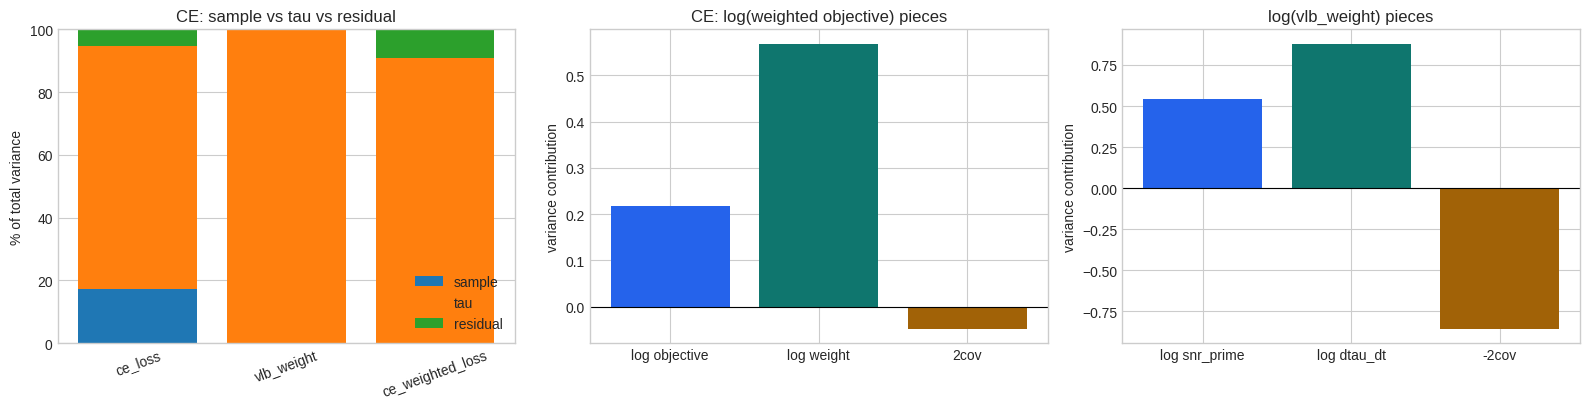

In [43]:
diagnostics = {
    'l2': run_variance_diagnostics(curves, objective='l2'),
    'ce': run_variance_diagnostics(curves, objective='ce'),
}
plot_variance_diagnostics(curves, diagnostics['l2'], objective='l2')
plot_variance_diagnostics(curves, diagnostics['ce'], objective='ce');

In [44]:
LABELS = {
    'loss': 'token-mean L2 loss',
    'loss_for_vlb': 'L2 loss after learnable weighting',
    'ce_loss': 'token-mean CE loss',
    'ce_loss_for_vlb': 'CE loss after learnable weighting',
    'snr_prime_t': 'snr_prime_t',
    'dtau_dt': 'dtau_dt',
    'vlb_weight': 'vlb_weight',
    'weighted_loss': 'token-mean L2 loss * vlb_weight',
    'ce_weighted_loss': 'token-mean CE loss * vlb_weight',
}


def _positive_for_log(values):
    finite = values[np.isfinite(values)]
    return finite.size > 0 and np.nanmin(finite) > 0


def _format_axis(ax, values, log_y=LOG_Y):
    if log_y and _positive_for_log(values):
        ax.set_yscale('log')


def plot_single_sample_terms(curves, sample_index=0, quantities=PLOT_QUANTITIES,
                             log_y=LOG_Y):
    x = curves['tau']
    n_cols = 2
    n_rows = math.ceil(len(quantities) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3.5 * n_rows), sharex=True)
    axes = axes.reshape(-1)
    for ax, name in zip(axes, quantities):
        y = matrix_for(curves, name)[sample_index]
        ax.plot(x, y, lw=1.8, label=LABELS.get(name, name))
        ax.axhline(np.nanmean(y), color='black', ls='--', lw=1.0, label='tau average')
        _format_axis(ax, y, log_y=log_y)
        ax.set_title(LABELS.get(name, name))
        ax.set_xlabel('tau')
        ax.legend(frameon=False, fontsize=8)
    for ax in axes[len(quantities):]:
        ax.axis('off')
    fig.suptitle(f'Sample {sample_index}: terms across tau')
    fig.tight_layout()
    return fig


def plot_sample_grid(curves, quantity=GRID_QUANTITY, n=PLOT_N_SAMPLES,
                     grid_shape=(10, 10), log_y=LOG_Y):
    x = curves['tau']
    y = matrix_for(curves, quantity)
    n = min(int(n), y.shape[0], grid_shape[0] * grid_shape[1])
    rows, cols = grid_shape
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.55, rows * 1.25),
                             sharex=True)
    axes = axes.reshape(-1)
    for idx, ax in enumerate(axes):
        if idx >= n:
            ax.axis('off')
            continue
        values = y[idx]
        ax.plot(x, values, color='#2563eb', lw=0.9)
        ax.axhline(np.nanmean(values), color='#111827', ls='--', lw=0.8, alpha=0.75)
        _format_axis(ax, values, log_y=log_y)
        ax.set_title(str(idx), fontsize=8, pad=2)
        ax.tick_params(labelsize=6, length=2)
    fig.suptitle(
        f'{LABELS.get(quantity, quantity)} per sample; dashed line is per-sample tau average',
        y=1.01,
    )
    fig.tight_layout()
    return fig


def plot_aggregate_grid(curves, quantities=PLOT_QUANTITIES, shade=AGG_SHADE,
                        errorbar_every=ERRORBAR_EVERY, log_y=LOG_Y):
    x = curves['tau']
    rows = math.ceil(len(quantities) / 2)
    fig, axes = plt.subplots(rows, 2, figsize=(13, 4.2 * rows), sharex=True)
    axes = np.asarray(axes).reshape(-1)
    for ax, name in zip(axes, quantities):
        y = matrix_for(curves, name)
        mean = np.nanmean(y, axis=0)
        std = np.nanstd(y, axis=0)
        spread = None
        if shade == 'std':
            spread = std
        elif shade == 'sem':
            spread = std / math.sqrt(max(y.shape[0], 1))

        ax.plot(x, mean, color='#0f766e', lw=2.0, label='sample mean')
        ax.axhline(np.nanmean(mean), color='#111827', ls='--', lw=1.0,
                   label='tau average of mean')
        if spread is not None:
            lower = mean - spread
            upper = mean + spread
            if log_y and _positive_for_log(mean):
                tiny = np.nanmin(mean[mean > 0]) * 1e-3
                lower = np.maximum(lower, tiny)
            ax.fill_between(x, lower, upper, color='#14b8a6', alpha=0.18,
                            label=f'+/- {shade}')
            if errorbar_every and int(errorbar_every) > 0:
                step = int(errorbar_every)
                ax.errorbar(x[::step], mean[::step], yerr=spread[::step],
                            fmt='none', ecolor='#0f766e', alpha=0.45, lw=0.8)
        _format_axis(ax, mean, log_y=log_y)
        ax.set_title(LABELS.get(name, name))
        ax.set_xlabel('tau')
        ax.legend(frameon=False, fontsize=8)
    for ax in axes[len(quantities):]:
        ax.axis('off')
    fig.suptitle('Aggregate across data samples')
    fig.tight_layout()
    return fig

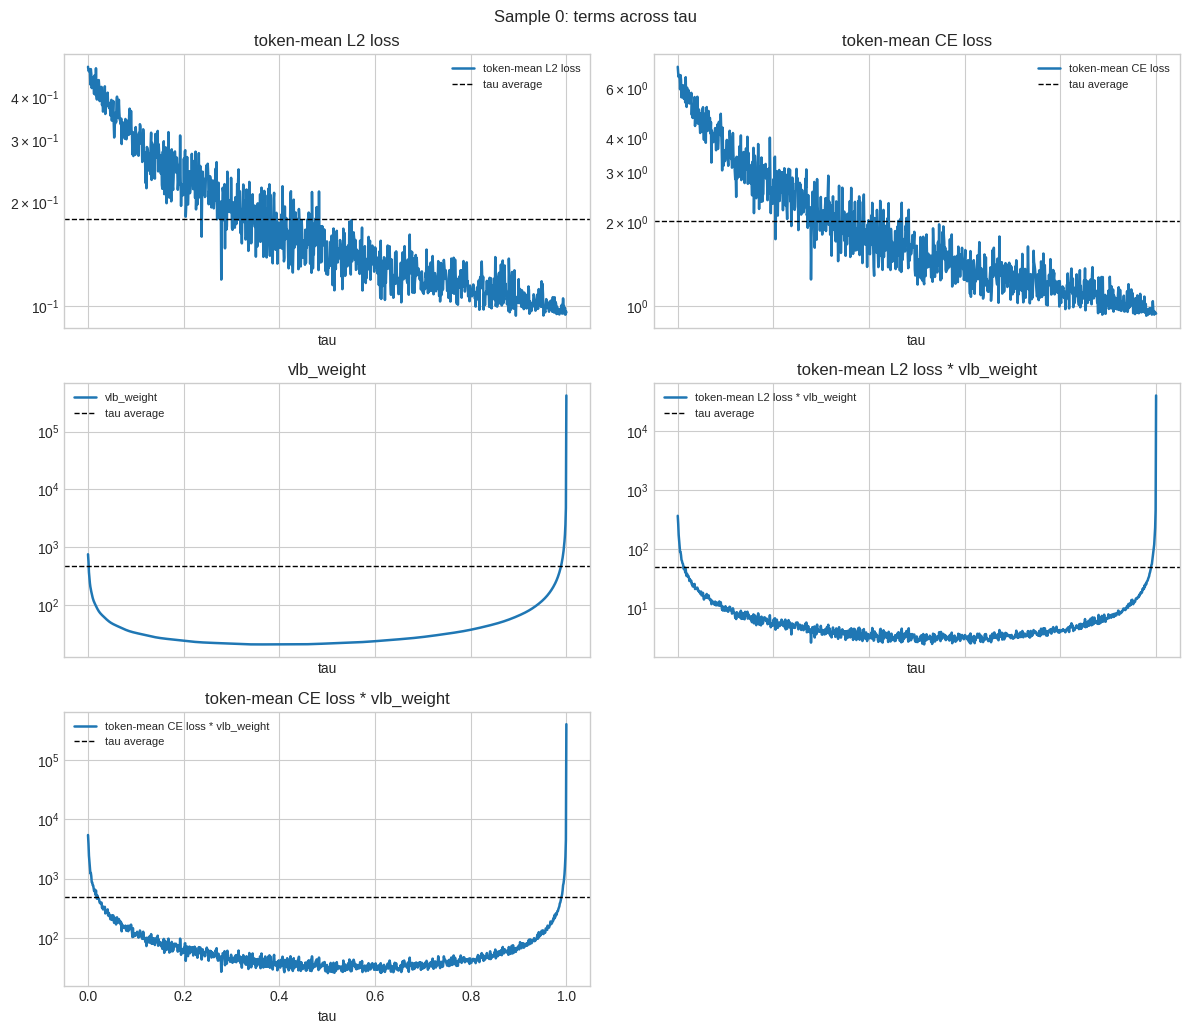

In [45]:
# A compact 2x2 view for one sample.
plot_single_sample_terms(curves, sample_index=0);

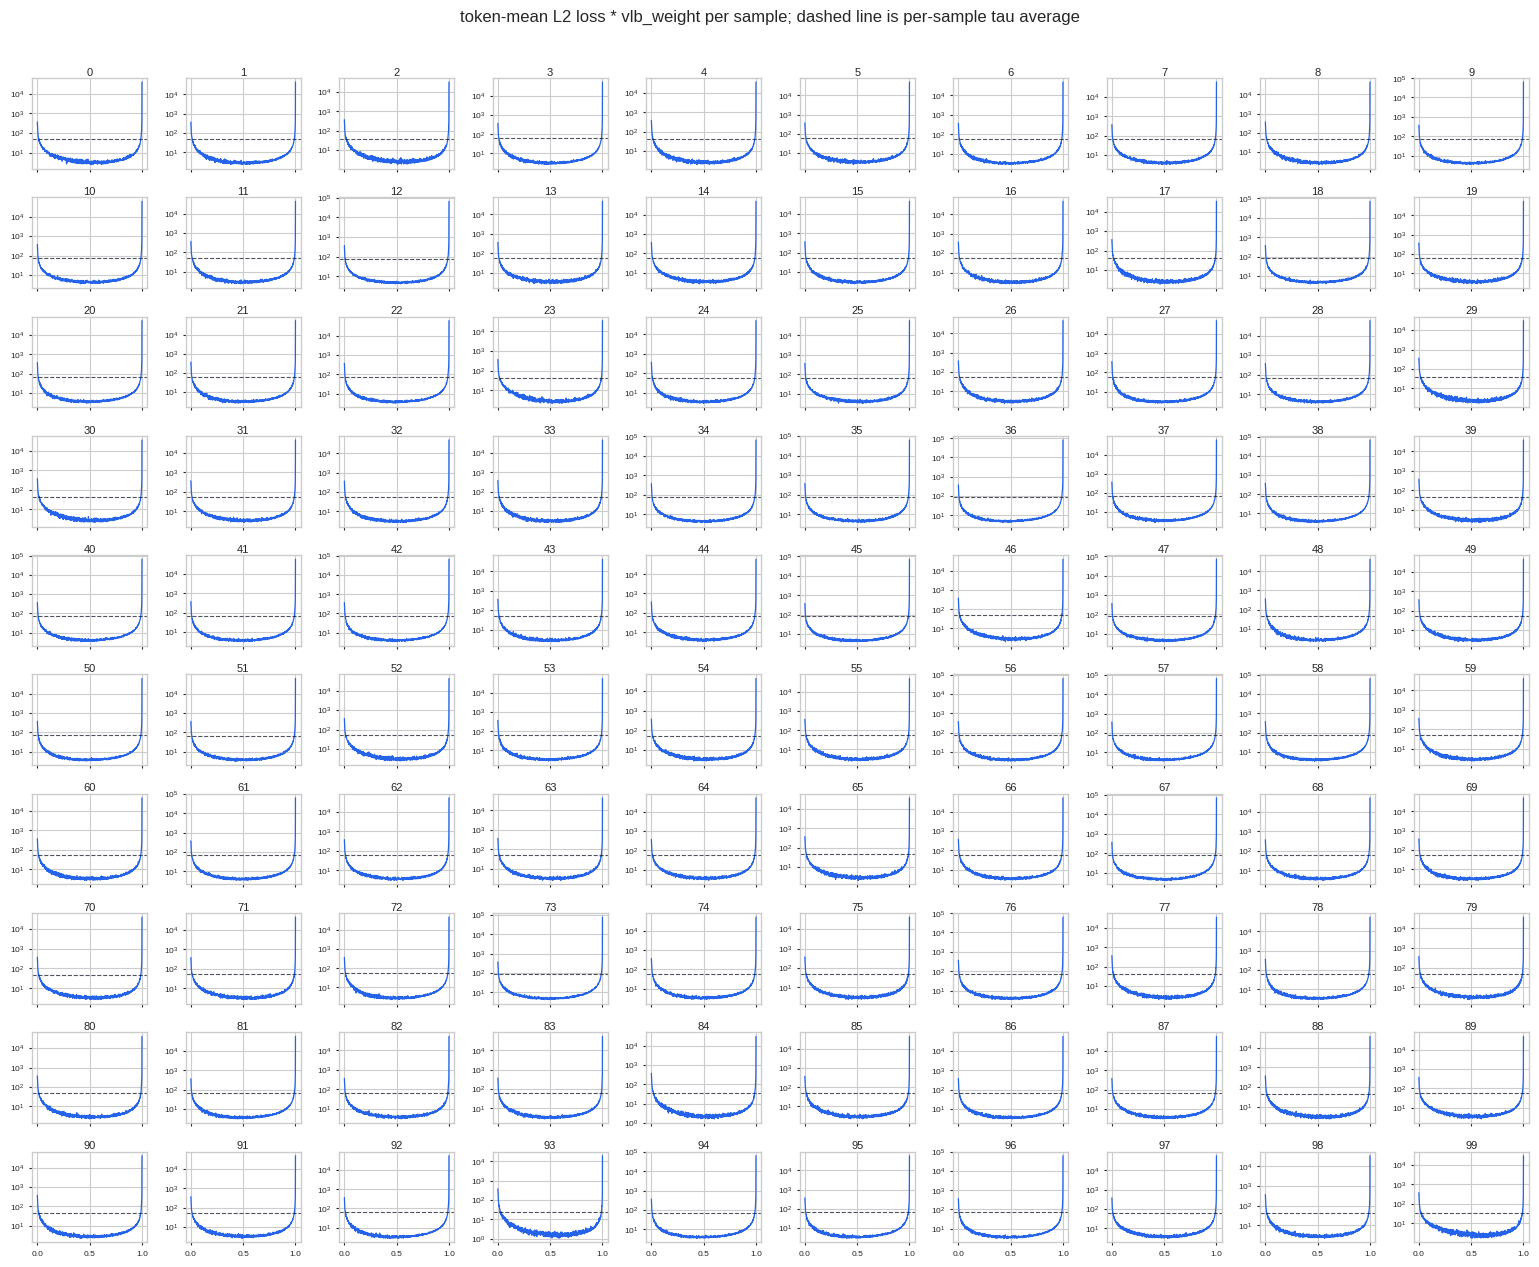

In [46]:
# 10x10 per-sample grid for one selected quantity.
# Change GRID_QUANTITY to 'loss', 'ce_loss', 'snr_prime_t', 'dtau_dt', 'vlb_weight', 'weighted_loss', or 'ce_weighted_loss'.
plot_sample_grid(curves, quantity=GRID_QUANTITY);

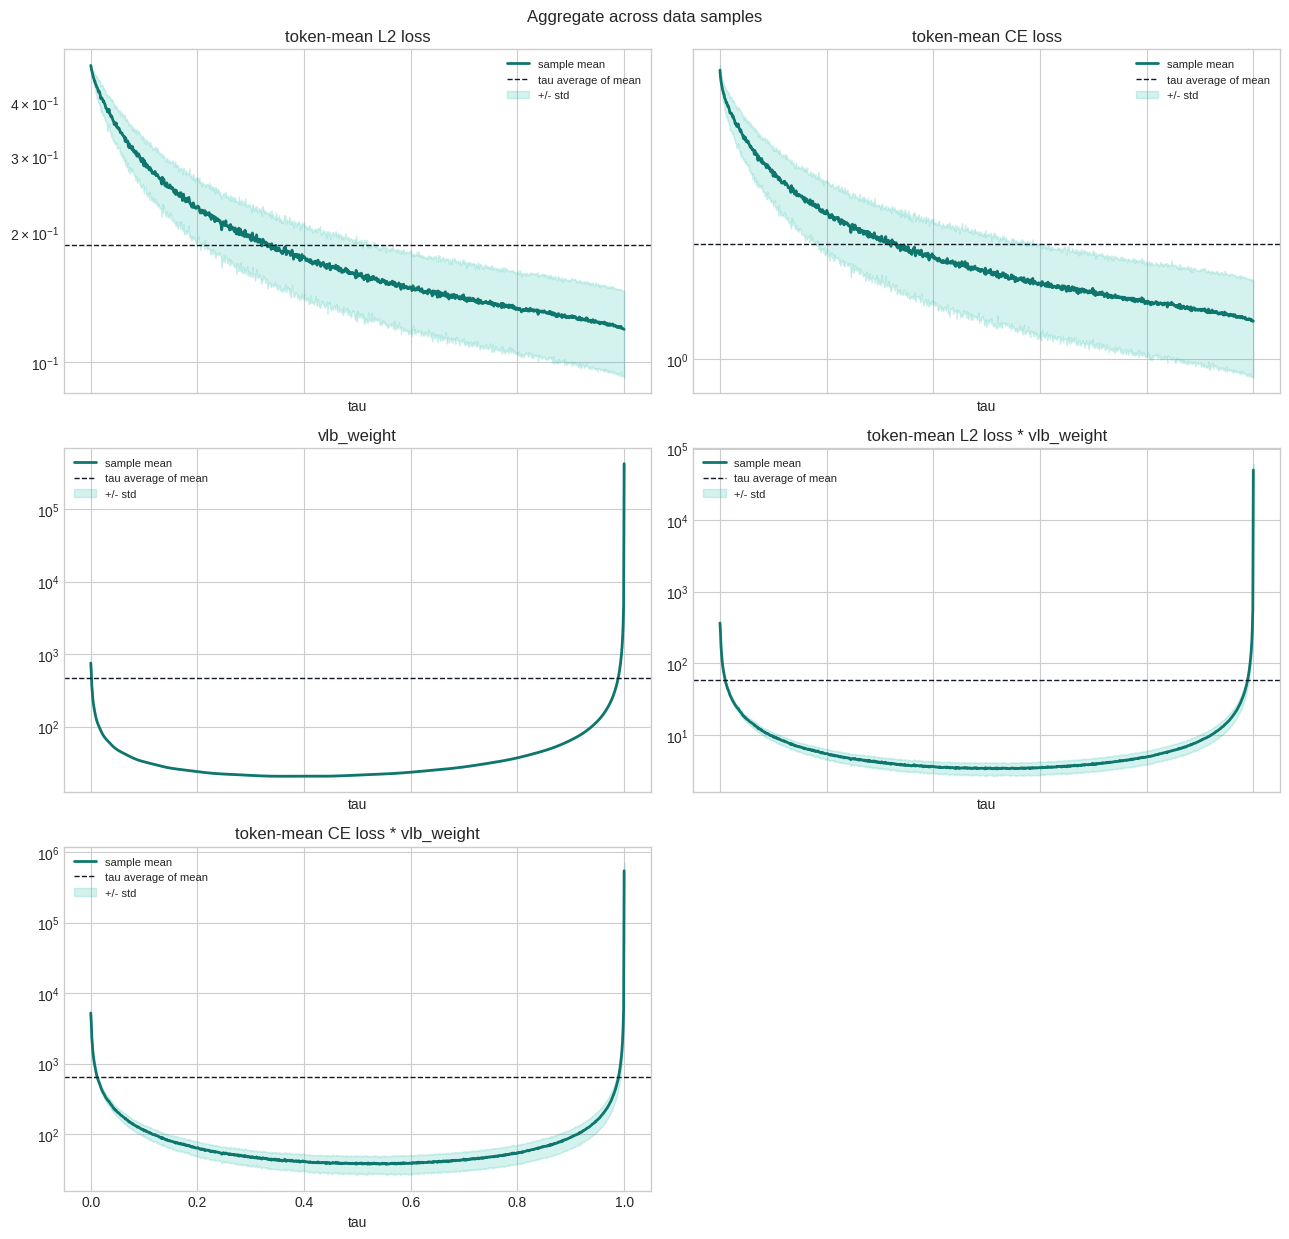

In [47]:
# Aggregate mean curve across samples, with std/sem shading.
plot_aggregate_grid(curves);

## Notes

- `FIXED_NOISE_PER_SAMPLE=False` mirrors the current loss path more closely: each `(sample, tau)` pair gets fresh Gaussian corruption noise.
- `FIXED_NOISE_PER_SAMPLE=True` reuses one corruption noise tensor for all taus of the same data sample, which can make tau-dependent structure easier to see.
- `weighted_loss` is token-reduced after multiplying by `vlb_weight`, matching the returned objective up to the outer training mask/reduction.
- `snr_prime_t`, `dtau_dt`, and `vlb_weight` are schedule-only terms, so their aggregate spread across data samples is expected to be zero when all samples share the same tau grid.